In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [33]:
from sklearn.metrics import ( # standard metrics to evaluate classification models
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    multilabel_confusion_matrix,
    roc_auc_score,
)
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [34]:
df = pd.read_csv('./dataset/DM1_game_dataset_cleaned.csv')

print(df.columns)

# check rank-rating relationship
print(df.groupby('Rating')['Rank'].median())
# percentage of each class
df['Rating'].value_counts(normalize=True) * 100

Index(['Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rating',
       'HasFamily', 'Category', 'Rank', 'EngagementLevel'],
      dtype='object')
Rating
High       1374.5
Low       21926.0
Medium     2851.5
Name: Rank, dtype: float64


Rating
Medium    44.051373
Low       33.095663
High      22.852964
Name: proportion, dtype: float64

In [35]:
from sklearn.preprocessing import KBinsDiscretizer, PowerTransformer

df = pd.read_csv('./dataset/DM1_game_dataset_cleaned.csv')

num_unranked = df[df['Rank'] == 21926].shape[0]
total = df.shape[0]
percentuale = (num_unranked / total) * 100
print(f"Giochi Unranked (21126): {num_unranked} su {total} ({percentuale:.2f}%)")

# median rank per rating
rating_median_rank = df.groupby('Rating')['Rank'].median()
print("Median Rank per Rating:")
print(rating_median_rank)

numeric_features = [
    'YearPublished', 'GameWeight', 'MinPlayers', 'MfgAgeRec' , 'NumImplementations','EngagementLevel', 'MaxPlayers', 'NumExpansions'
]
# 'NumAlternates','MfgPlaytime',

# Variabili BINARIE (Già 0/1 - NON scalare)
binary_features = [
    'IsReimplementation', 'Kickstarted', 'HasFamily'
]

# Variabili da discretizzare
discretize_features = ['Rank']

# Variabili CATEGORICHE (Stringhe - Da fare OneHot)
categorical_features = ['Category']

features_to_use = numeric_features + binary_features + categorical_features + discretize_features

# IMPORTANTE: X deve rimanere un DataFrame, NON usare .values
X = df[features_to_use] 
y = df['Rating']

# Creiamo il Preprocessing
# - Per le categoriche: OneHotEncoder (trasforma 'Wargame' in [1, 0, 0...])
# - Per le numeriche: StandardScaler (opzionale per NB, ma buona prassi per uniformare le scale)
preprocessor = ColumnTransformer(
    transformers=[
        # A. Numeriche -> StandardScaler (per uniformare le gaussiane)
        ('num', StandardScaler(), numeric_features),
        #('num', PowerTransformer(method='yeo-johnson'), numeric_features),
        # B. Binarie -> 'passthrough' (Le lasciamo passare così come sono, 0 e 1)
        ('bin', 'passthrough', binary_features),
        
        # C. Categoriche -> OneHotEncoder
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ])

Giochi Unranked (21126): 11183 su 21879 (51.11%)
Median Rank per Rating:
Rating
High       1374.5
Low       21926.0
Medium     2851.5
Name: Rank, dtype: float64


## Partitioning

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
random_state = 0

# stratified split to maintain class distribution in train and test sets

X_train, X_test, y_train, y_test = train_test_split( # 70% train, 30% test
    X, y, test_size=0.3, stratify=y, random_state=random_state 
)
print(X_train.shape, X_test.shape)
print(np.unique(y, return_counts=True)[1] / len(y))
print(np.unique(y_train, return_counts=True)[1] / len(y_train))
print(np.unique(y_test, return_counts=True)[1] / len(y_test))

(15315, 13) (6564, 13)
[0.22852964 0.33095663 0.44051373]
[0.22853412 0.3309827  0.44048319]
[0.2285192  0.3308958  0.44058501]


## Naive Bayes

In [38]:
from sklearn.naive_bayes import GaussianNB, CategoricalNB

Accuratezza: 0.4936014625228519

Report di Classificazione:
               precision    recall  f1-score   support

        High       0.41      0.77      0.54      1500
         Low       0.54      0.69      0.60      2172
      Medium       0.59      0.21      0.31      2892

    accuracy                           0.49      6564
   macro avg       0.51      0.55      0.48      6564
weighted avg       0.53      0.49      0.46      6564



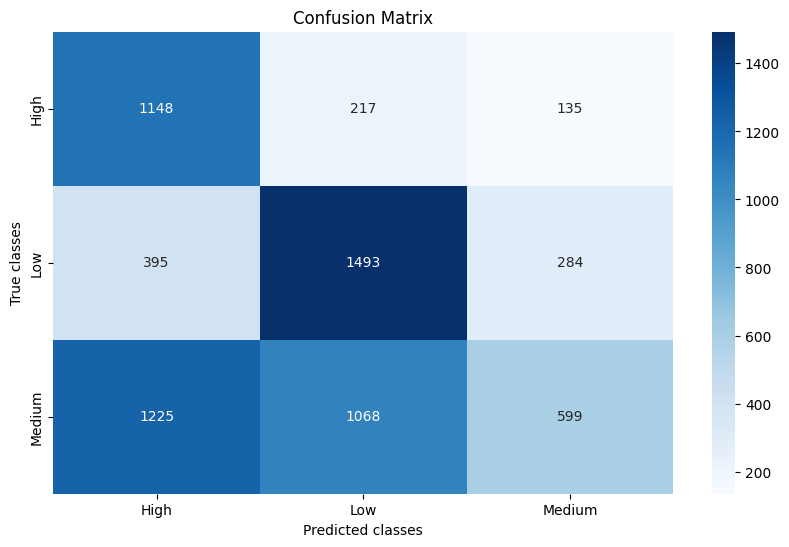

In [39]:
# Usiamo GaussianNB perché gestisce bene i continui e i categorici one-hot (che sono 0 o 1)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB()) # probability density estimation assuming Gaussian distribution of continuous features due to StandardScaler
])

# Training del modello
model.fit(X_train, y_train)

# Evaluation del modello
y_pred = model.predict(X_test)

print("Accuratezza:", accuracy_score(y_test, y_pred))
print("\nReport di Classificazione:\n", classification_report(y_test, y_pred))
# macro avg: averaging the unweighted mean per label
# weighted average: averaging the support-weighted mean per label
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
# order labels ['high', 'medium', 'medium']
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted classes')
plt.ylabel('True classes')
plt.title('Confusion Matrix')
plt.show()

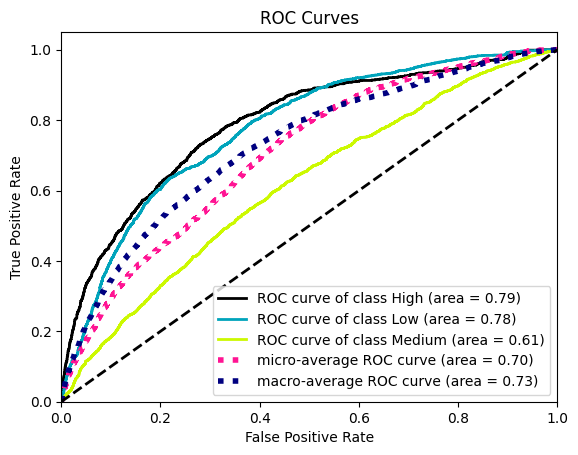

0.7256901544614388


In [40]:
# https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html
plot_roc(y_test, model.predict_proba(X_test))
plt.show()
print(roc_auc_score(y_test, model.predict_proba(X_test), multi_class="ovr", average="macro"))

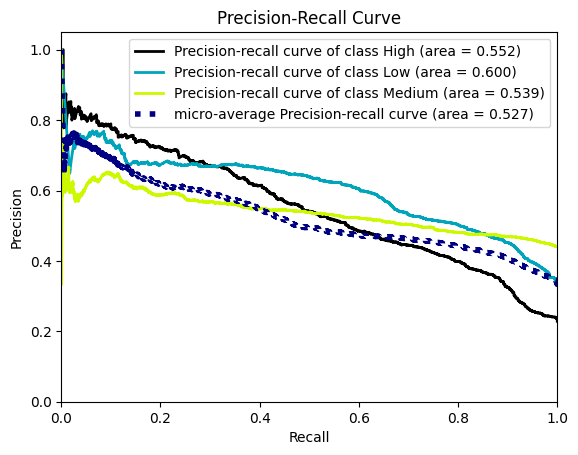

In [41]:
# Precision-Recall Curve
y_test_pred_proba = model.predict_proba(X_test)
plot_precision_recall(y_test, y_test_pred_proba)
plt.show()

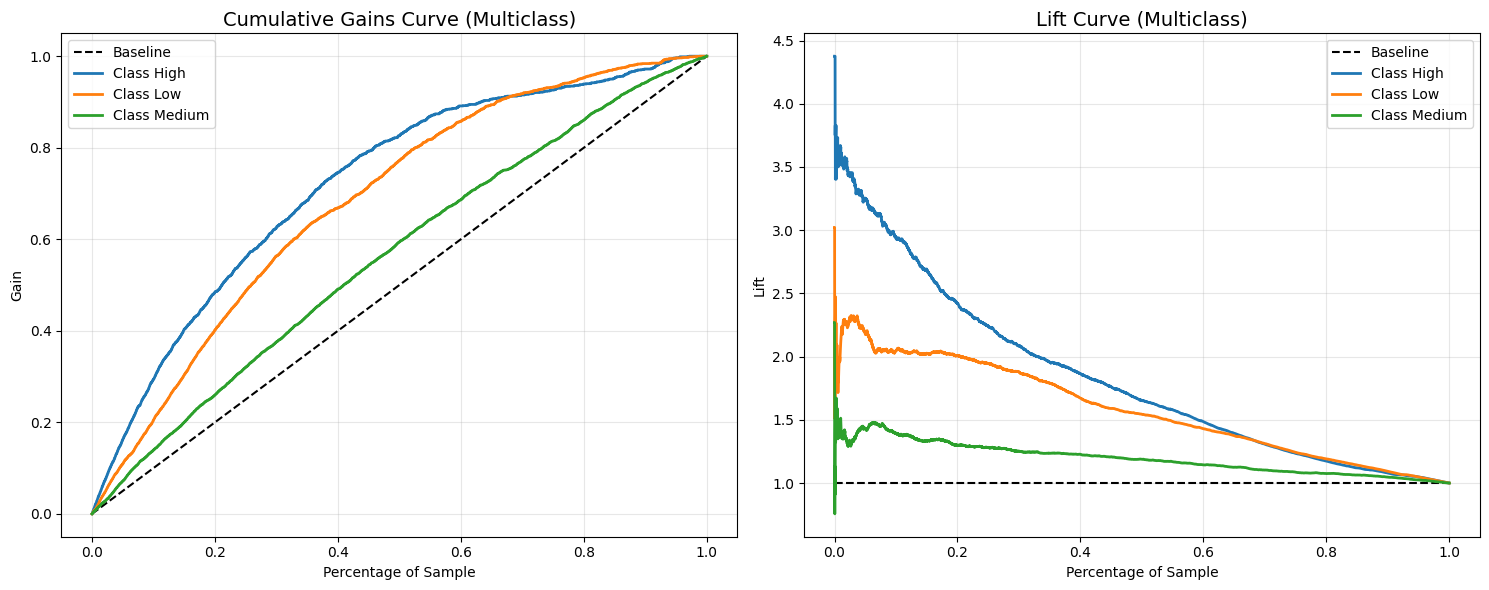

In [42]:
# Cumulative Gain (percetage of TP / number of cases ordered by probability P(Y|A)) and Lift Curve (%Gain / %sample)
import scikitplot as skplt

# 1. Recupera le classi e le probabilità
classes = model.classes_  # Es. ['Alto', 'Basso', 'Medio']

# 2. Imposta il plot
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: CUMULATIVE GAIN CURVE ---
axs[0].set_title('Cumulative Gains Curve (Multiclass)', fontsize=14)
axs[0].plot([0, 1], [0, 1], 'k--', label='Baseline') # Linea diagonale base

for i, class_label in enumerate(classes):
    # A. Binarizza y_test per la classe corrente (1 se è la classe corrente, 0 altrimenti)
    # Gestisce sia stringhe che numeri
    y_test_binary = (y_test == class_label).astype(int)
    
    # B. Prendi le probabilità SOLO di questa classe
    y_prob_class = y_test_pred_proba[:, i]
    
    # C. Calcola la curva usando la funzione di scikit-plot
    # Nota: richiede y_true binario e y_score della classe positiva
    percentages, gains = skplt.metrics.cumulative_gain_curve(y_test_binary, y_prob_class)
    
    # D. Plotta
    axs[0].plot(percentages, gains, lw=2, label=f'Class {class_label}')

axs[0].set_xlabel('Percentage of Sample')
axs[0].set_ylabel('Gain')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# --- PLOT 2: LIFT CURVE ---
axs[1].set_title('Lift Curve (Multiclass)', fontsize=14)
axs[1].plot([0, 1], [1, 1], 'k--', label='Baseline') # Linea orizzontale a 1

for i, class_label in enumerate(classes):
    y_test_binary = (y_test == class_label).astype(int)
    y_prob_class = y_test_pred_proba[:, i]
    
    # Calcolo curve Gain
    percentages, gains = skplt.metrics.cumulative_gain_curve(y_test_binary, y_prob_class)
    
    # Calcolo Lift manualmente dai dati del Gain
    # Lift = Gain / Percentage
    # Gestiamo la divisione per zero al primo punto
    lift = np.zeros_like(gains)
    # Evitiamo warning divisione per zero (il primo punto è 0/0)
    lift[1:] = gains[1:] / percentages[1:]
    lift[0] = lift[1] # Approssimazione per il punto zero
    
    axs[1].plot(percentages, lift, lw=2, label=f'Class {class_label}')

axs[1].set_xlabel('Percentage of Sample')
axs[1].set_ylabel('Lift')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analyzing P(X|Y)

Feature: YearPublished, Class: High, Mean: 2000.17, Std: 168.74
Feature: YearPublished, Class: Low, Mean: 1961.64, Std: 292.68
Feature: YearPublished, Class: Medium, Mean: 1992.68, Std: 173.13


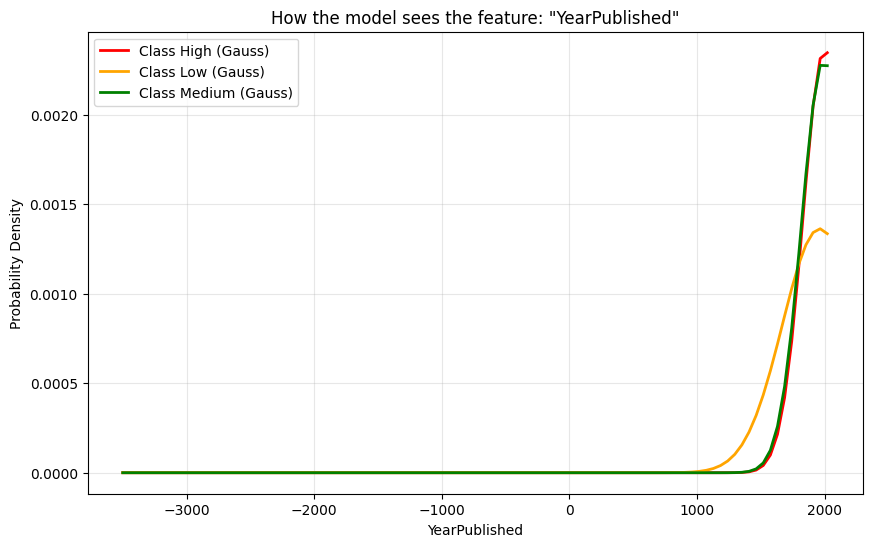

Feature: GameWeight, Class: High, Mean: 2.63, Std: 0.81
Feature: GameWeight, Class: Low, Mean: 1.60, Std: 0.60
Feature: GameWeight, Class: Medium, Mean: 2.02, Std: 0.71


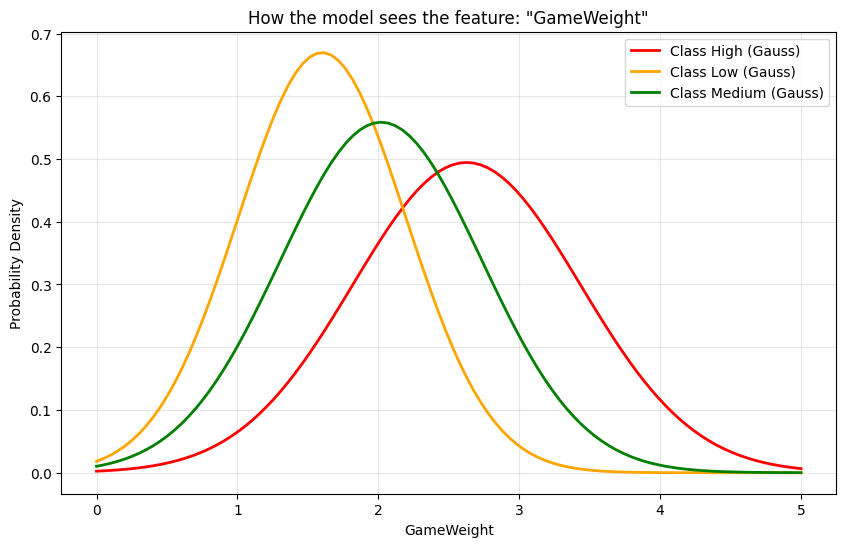

Feature: MinPlayers, Class: High, Mean: 1.78, Std: 0.66
Feature: MinPlayers, Class: Low, Mean: 2.12, Std: 0.61
Feature: MinPlayers, Class: Medium, Mean: 2.05, Std: 0.72


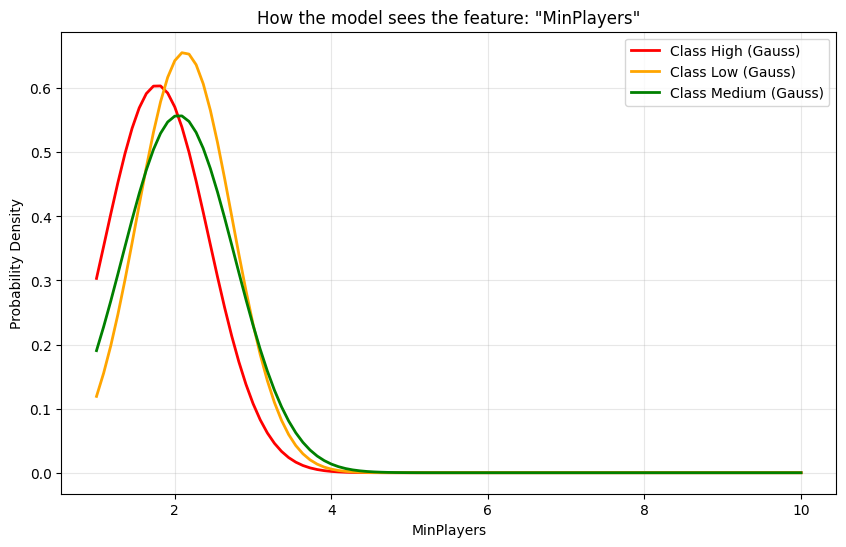

Feature: MfgAgeRec, Class: High, Mean: 11.44, Std: 2.19
Feature: MfgAgeRec, Class: Low, Mean: 9.34, Std: 2.92
Feature: MfgAgeRec, Class: Medium, Mean: 10.25, Std: 2.48


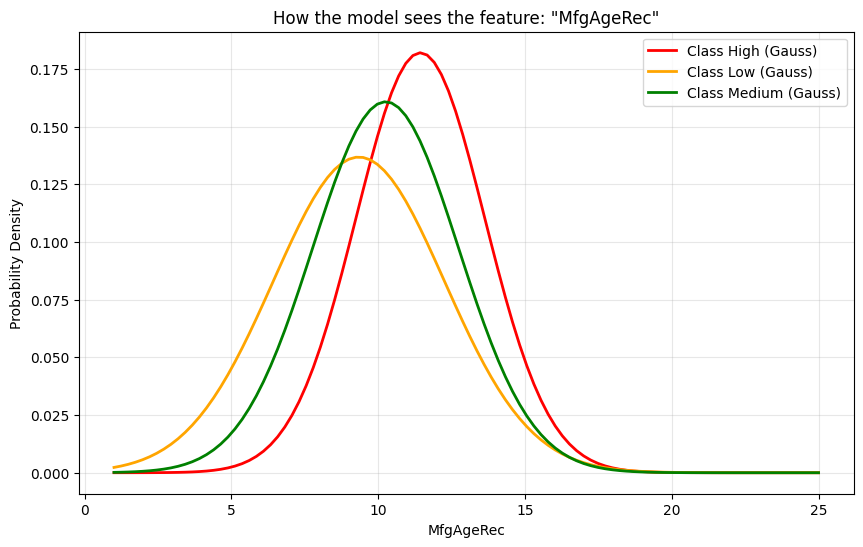

Feature: NumImplementations, Class: High, Mean: 0.23, Std: 0.40
Feature: NumImplementations, Class: Low, Mean: 0.11, Std: 0.30
Feature: NumImplementations, Class: Medium, Mean: 0.20, Std: 0.37


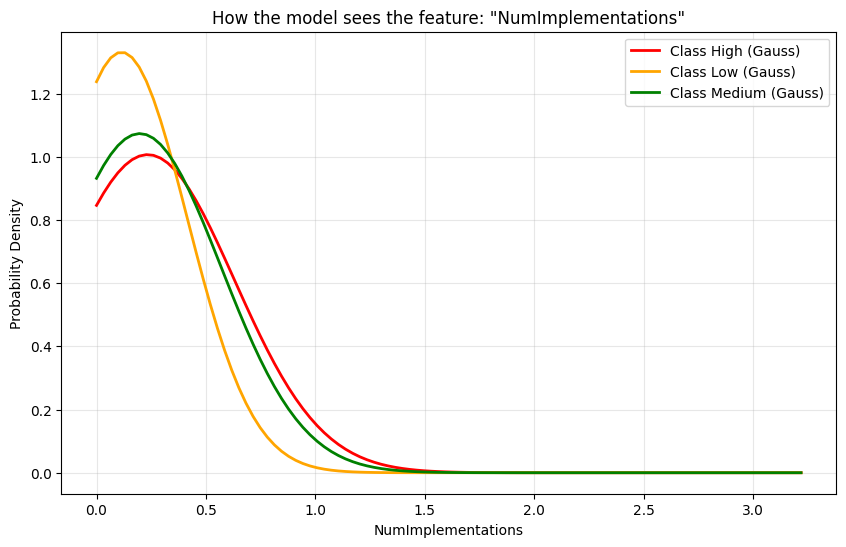

Feature: EngagementLevel, Class: High, Mean: 5.52, Std: 1.71
Feature: EngagementLevel, Class: Low, Mean: 4.12, Std: 0.95
Feature: EngagementLevel, Class: Medium, Mean: 4.92, Std: 1.34


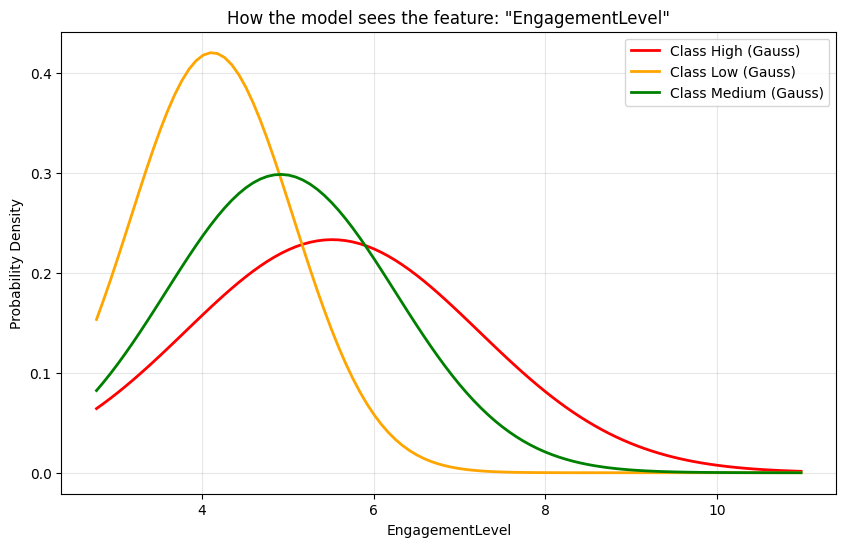

Feature: MaxPlayers, Class: High, Mean: 4.89, Std: 8.84
Feature: MaxPlayers, Class: Low, Mean: 6.67, Std: 18.24
Feature: MaxPlayers, Class: Medium, Mean: 5.53, Std: 14.67


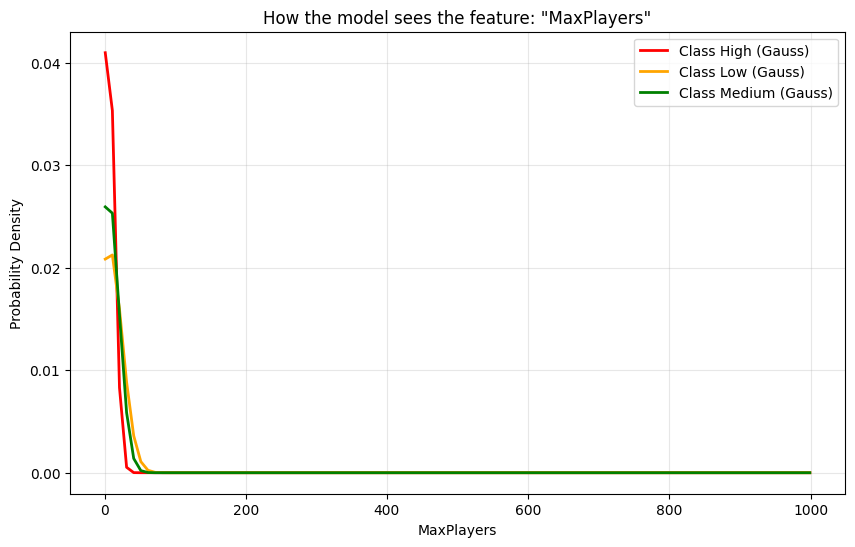

Feature: NumExpansions, Class: High, Mean: 0.69, Std: 0.96
Feature: NumExpansions, Class: Low, Mean: 0.11, Std: 0.39
Feature: NumExpansions, Class: Medium, Mean: 0.32, Std: 0.65


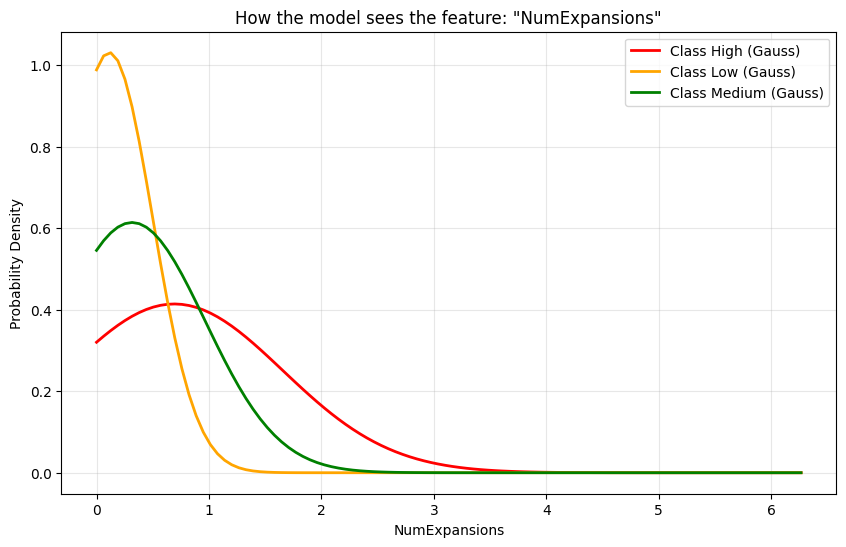

In [43]:
import scipy.stats as stats

for i in range(len(numeric_features)):
    feature_to_check = numeric_features[i]
    plt.figure(figsize=(10, 6))

    # Itera sulle 3 classi (Low, Medium, High)
    # Assicurati che le etichette in y_train siano quelle corrette (es. 0, 1, 2 o stringhe)
    classes = sorted(y_train.unique())
    colors = ['red', 'orange', 'green'] # Adatta i colori al significato (es. Low=Red, High=Green)

    for label, color in zip(classes, colors):
        # 1. Estrai i dati reali per questa classe
        data = X_train.loc[y_train == label, feature_to_check]
        
        # 2. Calcola Media e Deviazione Standard (quello che fa GaussianNB)
        mu = data.mean()
        sigma = data.std()
        
        # 3. Genera la curva Gaussiana teorica
        x = np.linspace(X_train[feature_to_check].min(), X_train[feature_to_check].max(), 100)
        plt.plot(x, stats.norm.pdf(x, mu, sigma), label=f'Class {label} (Gauss)', color=color, linewidth=2)
        
        # 4. (Opzionale) Mostra i dati reali sotto per confronto
        #sns.kdeplot(data, color=color, fill=True, alpha=0.1)

        # 5. stampa medie
        print(f'Feature: {feature_to_check}, Class: {label}, Mean: {mu:.2f}, Std: {sigma:.2f}')
        
    plt.title(f'How the model sees the feature: "{feature_to_check}"')
    plt.xlabel(feature_to_check)
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()





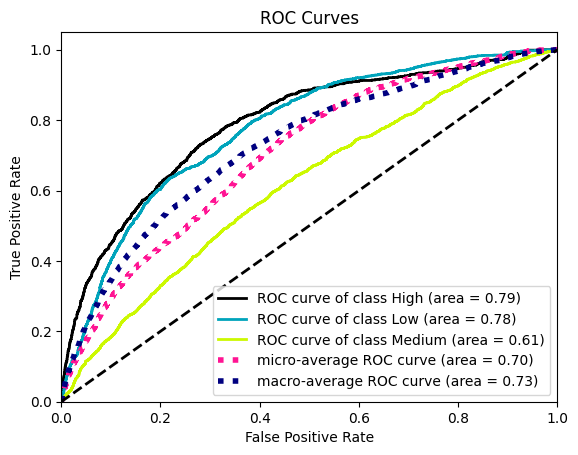

0.7256901544614388


In [44]:
# https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html
plot_roc(y_test, model.predict_proba(X_test))
plt.show()
print(roc_auc_score(y_test, model.predict_proba(X_test), multi_class="ovr", average="macro"))

## Cross-Validation to confirm the results

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Definiamo la strategia di CV (es. 10 Fold per essere molto robusti)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Definiamo quali metriche vogliamo monitorare
scoring = ['accuracy', 'recall_macro', 'recall_weighted']

# Eseguiamo la Cross-Validation sull'INTERO dataset X, y (non solo train)
# La pipeline gestirà il fit/transform automaticamente per ogni fold
scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

# Stampiamo i risultati
print(f"Accuracy media: {scores['test_accuracy'].mean():.4f} (+/- {scores['test_accuracy'].std():.4f})")
print(f"Recall Macro media: {scores['test_recall_macro'].mean():.4f} (+/- {scores['test_recall_macro'].std():.4f})")
print(f"Recall Weighted media: {scores['test_recall_weighted'].mean():.4f} (+/- {scores['test_recall_weighted'].std():.4f})")

Accuracy media: 0.4874 (+/- 0.0080)
Recall Macro media: 0.5475 (+/- 0.0073)
Recall Weighted media: 0.4874 (+/- 0.0080)


## Performances with Rank variable

In [46]:
from sklearn.preprocessing import KBinsDiscretizer, PowerTransformer

df = pd.read_csv('./dataset/DM1_game_dataset_cleaned.csv')

num_unranked = df[df['Rank'] == 21926].shape[0]
total = df.shape[0]
percentuale = (num_unranked / total) * 100
print(f"Giochi Unranked (21126): {num_unranked} su {total} ({percentuale:.2f}%)")

# median rank per rating
rating_median_rank = df.groupby('Rating')['Rank'].median()
print("Median Rank per Rating:")
print(rating_median_rank)

numeric_features = [
    'YearPublished', 'GameWeight', 'MinPlayers', 'MfgAgeRec' , 'NumImplementations','EngagementLevel', 'MaxPlayers', 'NumExpansions'
]
# 'NumAlternates','MfgPlaytime',

# Variabili BINARIE (Già 0/1 - NON scalare)
binary_features = [
    'IsReimplementation', 'Kickstarted', 'HasFamily'
]

# Variabili da discretizzare
discretize_features = ['Rank']

# Variabili CATEGORICHE (Stringhe - Da fare OneHot)
categorical_features = ['Category']

features_to_use = numeric_features + binary_features + categorical_features + discretize_features

# IMPORTANTE: X deve rimanere un DataFrame, NON usare .values
X = df[features_to_use] 
y = df['Rating']

# Creiamo il Preprocessing
# - Per le categoriche: OneHotEncoder (trasforma 'Wargame' in [1, 0, 0...])
# - Per le numeriche: StandardScaler (opzionale per NB, ma buona prassi per uniformare le scale)
preprocessor = ColumnTransformer(
    transformers=[
        # A. Numeriche -> StandardScaler (per uniformare le gaussiane)
        ('num', StandardScaler(), numeric_features),
        #('num', PowerTransformer(method='yeo-johnson'), numeric_features),
        # B. Binarie -> 'passthrough' (Le lasciamo passare così come sono, 0 e 1)
        ('bin', 'passthrough', binary_features),
        
        # C. Categoriche -> OneHotEncoder
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),

        # D. Discretizzazione per Rank
        ('discretizer', KBinsDiscretizer(n_bins=4, encode='onehot-dense', strategy='quantile'), discretize_features)
    ])

Giochi Unranked (21126): 11183 su 21879 (51.11%)
Median Rank per Rating:
Rating
High       1374.5
Low       21926.0
Medium     2851.5
Name: Rank, dtype: float64


In [47]:
random_state = 0

# stratified split to maintain class distribution in train and test sets

X_train, X_test, y_train, y_test = train_test_split( # 70% train, 30% test
    X, y, test_size=0.3, stratify=y, random_state=random_state 
)
print(X_train.shape, X_test.shape)
print(np.unique(y, return_counts=True)[1] / len(y))
print(np.unique(y_train, return_counts=True)[1] / len(y_train))
print(np.unique(y_test, return_counts=True)[1] / len(y_test))

(15315, 13) (6564, 13)
[0.22852964 0.33095663 0.44051373]
[0.22853412 0.3309827  0.44048319]
[0.2285192  0.3308958  0.44058501]


c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


Accuratezza: 0.5083790371724558

Report di Classificazione:
               precision    recall  f1-score   support

        High       0.44      0.76      0.55      1500
         Low       0.54      0.70      0.61      2172
      Medium       0.60      0.23      0.34      2892

    accuracy                           0.51      6564
   macro avg       0.52      0.56      0.50      6564
weighted avg       0.54      0.51      0.48      6564



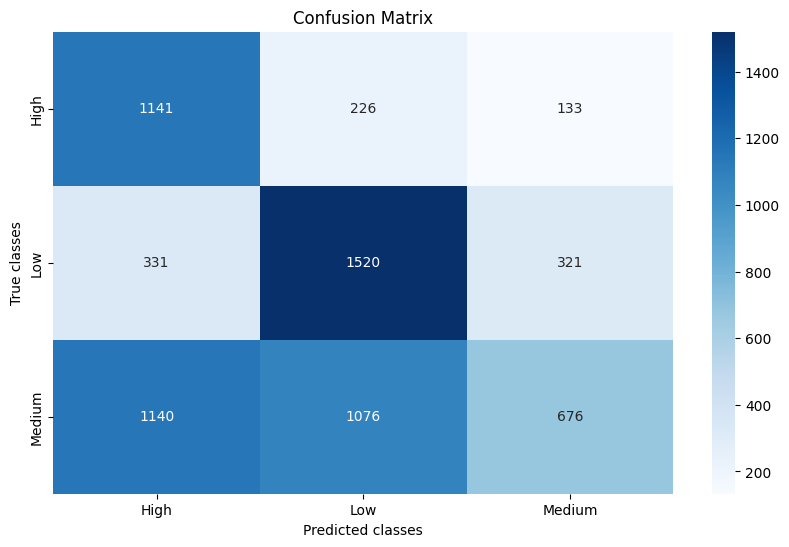

In [48]:
# Usiamo GaussianNB perché gestisce bene i continui e i categorici one-hot (che sono 0 o 1)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB()) # probability density estimation assuming Gaussian distribution of continuous features due to StandardScaler
])

# Training del modello
model.fit(X_train, y_train)

# Evaluation del modello
y_pred = model.predict(X_test)

print("Accuratezza:", accuracy_score(y_test, y_pred))
print("\nReport di Classificazione:\n", classification_report(y_test, y_pred))
# macro avg: averaging the unweighted mean per label
# weighted average: averaging the support-weighted mean per label
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
# order labels ['high', 'medium', 'medium']
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted classes')
plt.ylabel('True classes')
plt.title('Confusion Matrix')
plt.show()

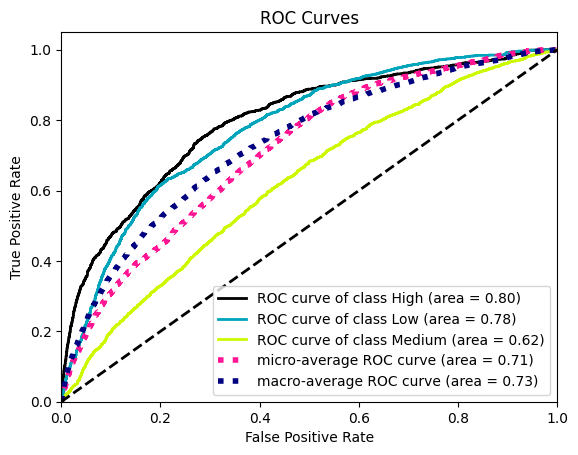

0.732152737436279


In [49]:
# ROC Curve
plot_roc(y_test, model.predict_proba(X_test))
plt.show()
print(roc_auc_score(y_test, model.predict_proba(X_test), multi_class="ovr", average="macro"))

In [50]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Definiamo la strategia di CV (es. 10 Fold per essere molto robusti)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Definiamo quali metriche vogliamo monitorare
scoring = ['accuracy', 'recall_macro', 'recall_weighted']

# Eseguiamo la Cross-Validation sull'INTERO dataset X, y (non solo train)
# La pipeline gestirà il fit/transform automaticamente per ogni fold
scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

# Stampiamo i risultati
print(f"Accuracy media: {scores['test_accuracy'].mean():.4f} (+/- {scores['test_accuracy'].std():.4f})")
print(f"Recall Macro media: {scores['test_recall_macro'].mean():.4f} (+/- {scores['test_recall_macro'].std():.4f})")
print(f"Recall Weighted media: {scores['test_recall_weighted'].mean():.4f} (+/- {scores['test_recall_weighted'].std():.4f})")

Accuracy media: 0.4988 (+/- 0.0068)
Recall Macro media: 0.5548 (+/- 0.0062)
Recall Weighted media: 0.4988 (+/- 0.0068)
